In [1]:
"""
V&A API Explorer - Step 1
Just look at what the data looks like before doing anything with it.

Run this first and examine the output carefully.
"""

import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random
from collections import Counter

BASE_URL = "https://api.vam.ac.uk/v2"

def fetch_sample(query="textile", page_size=3):
    """Fetch a small sample and print the raw structure."""
    
    url = f"{BASE_URL}/objects/search"
    params = {
        "q": query,
        "page_size": page_size,
        "page": 1
    }
    
    print(f"Fetching: {url}")
    print(f"Parameters: {params}\n")
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()
    
    # --- Top level structure ---
    print("=== TOP LEVEL KEYS ===")
    for key in data.keys():
        print(f"  {key}")
    
    # --- Info block ---
    print("\n=== INFO (pagination etc.) ===")
    print(json.dumps(data.get("info", {}), indent=2))
    
    # --- First record, full dump ---
    records = data.get("records", [])
    print(f"\n=== TOTAL RECORDS AVAILABLE: {data.get('info', {}).get('record_count', '?')} ===")
    print(f"=== RECORDS IN THIS PAGE: {len(records)} ===")
    
    print("\n=== FIRST RECORD (full) ===")
    if records:
        print(json.dumps(records[0], indent=2))
    
    # --- Field summary across all records in page ---
    print("\n=== FIELDS PRESENT ACROSS ALL RECORDS ===")
    all_fields = set()
    for record in records:
        all_fields.update(record.keys())
    for field in sorted(all_fields):
        print(f"  {field}")
    
    return data


if __name__ == "__main__":
    data = fetch_sample(query="textile", page_size=3)

print("\n=== CLUSTERS ===")
print(json.dumps(data.get("clusters", {}), indent=2))

Fetching: https://api.vam.ac.uk/v2/objects/search
Parameters: {'q': 'textile', 'page_size': 3, 'page': 1}

=== TOP LEVEL KEYS ===
  info
  records
  clusters

=== INFO (pagination etc.) ===
{
  "version": "2.0",
  "record_count": 106122,
  "record_count_exact": true,
  "parameters": {},
  "page_size": 3,
  "pages": 3324,
  "page": 1,
  "image_count": 189387
}

=== TOTAL RECORDS AVAILABLE: 106122 ===
=== RECORDS IN THIS PAGE: 3 ===

=== FIRST RECORD (full) ===
{
  "systemNumber": "O552918",
  "accessionNumber": "E.845-1978",
  "objectType": "Textile design",
  "availableToBook": false,
  "_currentLocation": {
    "id": "THES281347",
    "displayName": "On display in the Scottish Design Galleries, V&A Dundee",
    "type": "display",
    "site": "VADundee (LOAN)",
    "onDisplay": true,
    "detail": {
      "free": "",
      "case": "",
      "shelf": "",
      "box": ""
    }
  },
  "_primaryTitle": "Design for textile",
  "_primaryMaker": {
    "name": "Grant, Duncan",
    "association

import requests
import time
import pandas as pd

BASE_URL = "https://api.vam.ac.uk/v2"

def fetch_system_numbers(page=1, page_size=50):
    """Get a page of system numbers from the Theatre collection."""
    url = f"{BASE_URL}/objects/search"
    params = {
        "id_collection": "THES48602",
        "page_size": page_size,
        "page": page,
    }
    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()
    return [r["systemNumber"] for r in data["records"]]

def fetch_full_record(system_number):
    url = f"{BASE_URL}/object/{system_number}"
    response = requests.get(url)
    response.raise_for_status()
    return response.json()["record"]

def extract_fields(record):
    year = None
    dates = record.get("productionDates", [])
    if dates:
        earliest = dates[0]["date"].get("earliest")
        latest = dates[0]["date"].get("latest")
        if earliest and latest:
            year = (int(earliest[:4]) + int(latest[:4])) // 2

    materials = [m["text"] for m in record.get("materials", [])]
    techniques = [t["text"] for t in record.get("techniques", [])]
    styles = [s["text"] for s in record.get("styles", [])]
    places = record.get("placesOfOrigin", [])
    place = places[0]["place"]["text"] if places else None

    return {
        "systemNumber": record.get("systemNumber"),
        "objectType": record.get("objectType"),
        "title": record.get("briefDescription") or (record.get("titles") or [{}])[0].get("title"),
        "maker": (record.get("artistMakerPerson") or [{}])[0].get("name", {}).get("text"),
        "year": year,
        "place": place,
        "materials": materials,
        "techniques": techniques,
        "styles": styles,
    }

# --- Main fetch loop ---
all_rows = []
target = 2000
page_size = 50
page = 1

print("Fetching records...")

while len(all_rows) < target:
    system_numbers = fetch_system_numbers(page=page, page_size=page_size)
    
    for sn in system_numbers:
        if len(all_rows) >= target:
            break
        try:
            record = fetch_full_record(sn)
            row = extract_fields(record)
            all_rows.append(row)
        except Exception as e:
            print(f"  Skipping {sn}: {e}")
        
        time.sleep(0.05)  # small pause to be polite to the API
    
    print(f"  Page {page} done — {len(all_rows)} records so far")
    page += 1

# --- Save ---
df = pd.DataFrame(all_rows)
df.to_csv("theatre_collection.csv", index=False)

print(f"\nDone! {len(df)} records saved to theatre_collection.csv")
print(df.shape)
print(df.head())

In [2]:
import pandas as pd

df = pd.read_csv("theatre_collection.csv")

print("Shape:", df.shape)
print()
print("Column types:")
print(df.dtypes)
print()
print("Missing values:")
print(df.isnull().sum())
print()
print("Sample rows:")
print(df.head())
print()
print("Object types:")
print(df["objectType"].value_counts().head(20))

Shape: (2000, 9)

Column types:
systemNumber     object
objectType       object
title            object
maker            object
year            float64
place            object
materials        object
techniques       object
styles           object
dtype: object

Missing values:
systemNumber      0
objectType        0
title             0
maker           650
year            138
place           299
materials         0
techniques        0
styles            0
dtype: int64

Sample rows:
  systemNumber      objectType  \
0      O152859       Set model   
1      O117473  Eye glass case   
2      O106013           Print   
3       O68867       Sculpture   
4       O97213  Theatre design   

                                               title             maker  \
0  Set model designed by John Napier for Andrew L...      Napier, John   
1  Glasses case owned by Edward Gordon Craig and ...           Unknown   
2  Marie Taglioni in <i>L'Ombre</i>.  Lithograph ...           Unknown   
3  Plaster po

In [3]:
# styles was saved as a string representation of a list
# let's see how many are actually populated
import ast

df["styles_parsed"] = df["styles"].apply(ast.literal_eval)
df["has_style"] = df["styles_parsed"].apply(lambda x: len(x) > 0)

print("Records with style data:", df["has_style"].sum())
print()
print("Records with materials:")
df["materials_parsed"] = df["materials"].apply(ast.literal_eval)
df["has_materials"] = df["materials_parsed"].apply(lambda x: len(x) > 0)
print(df["has_materials"].sum())

Records with style data: 1

Records with materials:
1859


In [4]:
print("Year range:")
print(df["year"].describe())
print()
print("Top materials:")
from collections import Counter
all_materials = [m for sublist in df["materials_parsed"] for m in sublist]
print(Counter(all_materials).most_common(20))

Year range:
count    1862.000000
mean     1870.338883
std        66.118302
min      1367.000000
25%      1836.250000
50%      1850.000000
75%      1919.000000
max      2020.000000
Name: year, dtype: float64

Top materials:
[('paper', 990), ('printing ink', 589), ('photographic paper', 497), ('ink', 379), ('paint', 209), ('wash', 96), ('wood', 95), ('gouache', 73), ('watercolour', 72), ('pencil', 66), ('card', 58), ('charcoal', 46), ('glue', 43), ('metal', 41), ('silk (textile)', 39), ('canvas', 27), ('plastic', 25), ('masking tape', 25), ('wire', 24), ('perspex', 22)]


In [5]:
import ast
import pandas as pd

# When does plastic first appear?
df["materials_parsed"] = df["materials"].apply(ast.literal_eval)

plastic_years = df[df["materials_parsed"].apply(
    lambda x: any("plastic" in m.lower() for m in x)
)]["year"].dropna()

photo_years = df[df["materials_parsed"].apply(
    lambda x: any("photographic" in m.lower() for m in x)
)]["year"].dropna()

print("Plastic — first appearance:", plastic_years.min())
print("Plastic — year range:", plastic_years.min(), "-", plastic_years.max())
print("Count:", len(plastic_years))
print()
print("Photographic paper — first appearance:", photo_years.min())
print("Photographic paper — year range:", photo_years.min(), "-", photo_years.max())
print("Count:", len(photo_years))

Plastic — first appearance: 1849.0
Plastic — year range: 1849.0 - 2005.0
Count: 32

Photographic paper — first appearance: 1787.0
Photographic paper — year range: 1787.0 - 1978.0
Count: 497


In [6]:
# Find the 1849 plastic object
early_plastic = df[
    df["materials_parsed"].apply(lambda x: any("plastic" in m.lower() for m in x)) &
    (df["year"] < 1900)
][["systemNumber", "title", "year", "materials_parsed", "objectType"]]

print("Suspicious plastic records:")
print(early_plastic.to_string())
print()

# Find the 1787 photographic paper object  
early_photo = df[
    df["materials_parsed"].apply(lambda x: any("photographic" in m.lower() for m in x)) &
    (df["year"] < 1850)
][["systemNumber", "title", "year", "materials_parsed", "objectType"]]

print("Suspicious photographic paper records:")
print(early_photo.to_string())

Suspicious plastic records:
    systemNumber                                              title    year                      materials_parsed       objectType
119     O1114858  Costume worn by Whimsical Walker (Thomas Dawson).  1849.0  [wool, plastic, cotton twill, braid]  Theatre costume

Suspicious photographic paper records:
     systemNumber                                                                                                                                                                 title    year      materials_parsed  objectType
1304     O1137682  Photograph of a pen and ink drawing by Alexandre Moitte depicting six characters in full costume in Nicholas Dezède's opera <i>Alcindor</i>. Harry Beard Collection.  1787.0  [photographic paper]  Photograph
1874      O230777                                                                                                      Photograph of Miss Elsworthy, ca. 19th c. Guy Little Collection.  1849.0  [photographic paper]  Pho

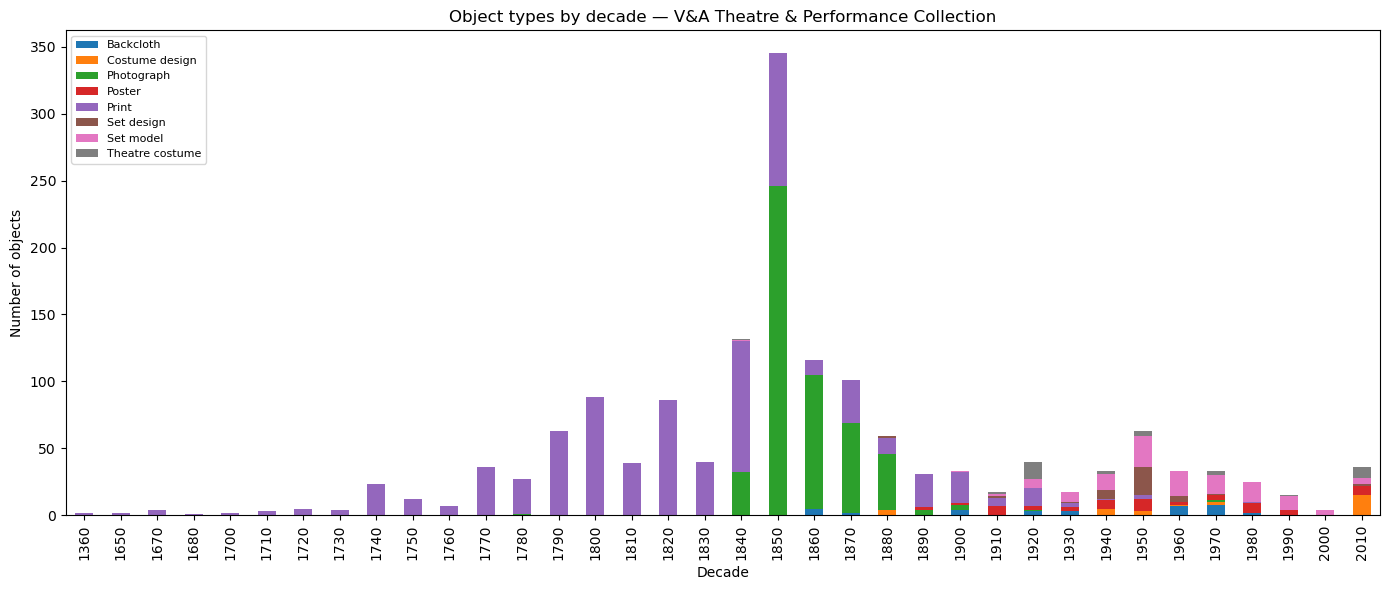

Saved!


In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Focus on the main object types
top_types = df["objectType"].value_counts().head(8).index

df_top = df[df["objectType"].isin(top_types) & df["year"].notna()]

# Bin years into decades
df_top = df_top.copy()
df_top["decade"] = (df_top["year"] // 10 * 10).astype(int)

# Count object types per decade
pivot = df_top.groupby(["decade", "objectType"]).size().unstack(fill_value=0)

pivot.plot(kind="bar", stacked=True, figsize=(14, 6))
plt.title("Object types by decade — V&A Theatre & Performance Collection")
plt.xlabel("Decade")
plt.ylabel("Number of objects")
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("object_types_by_decade.png", dpi=150)
plt.show()
print("Saved!")

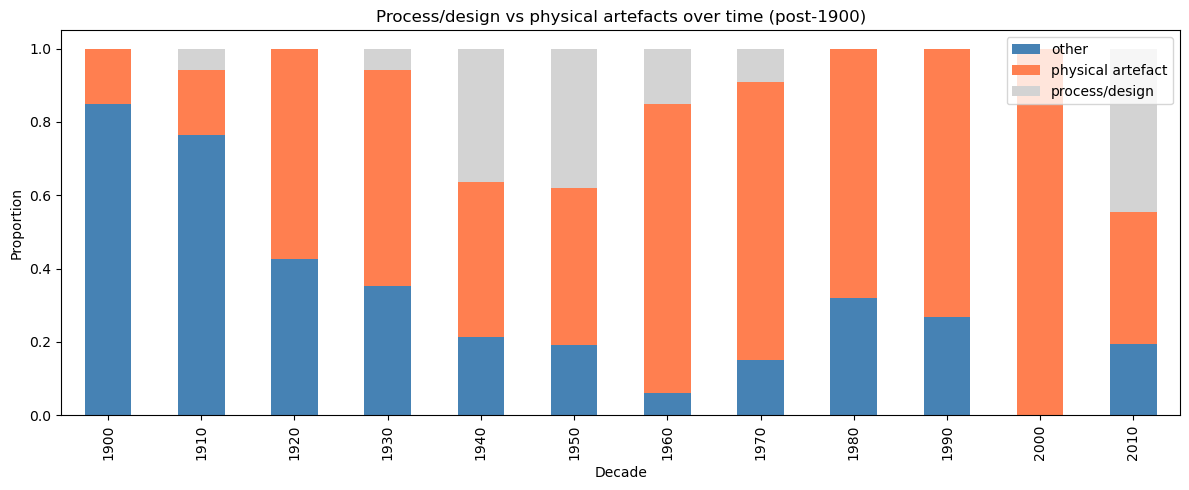

Done!


In [8]:
# Define "process" objects vs "artefact" objects
process_types = ["Costume design", "Set design", "Theatre design", "Drawing"]
artefact_types = ["Theatre costume", "Set model", "Backcloth", "Stage property"]

df_top = df_top.copy()
df_top["category"] = "other"
df_top.loc[df_top["objectType"].isin(process_types), "category"] = "process/design"
df_top.loc[df_top["objectType"].isin(artefact_types), "category"] = "physical artefact"

# Look at post-1900 only where both exist
df_modern = df_top[df_top["decade"] >= 1900]

pivot2 = df_modern.groupby(["decade", "category"]).size().unstack(fill_value=0)

# Normalise to proportions
pivot2_pct = pivot2.div(pivot2.sum(axis=1), axis=0)

pivot2_pct.plot(kind="bar", stacked=True, figsize=(12, 5), 
                color=["steelblue", "coral", "lightgrey"])
plt.title("Process/design vs physical artefacts over time (post-1900)")
plt.xlabel("Decade")
plt.ylabel("Proportion")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("process_vs_artefact.png", dpi=150)
plt.show()
print("Done!")

In [9]:


# Focus on post-1900, exclude documentation materials
# (paper, printing ink, photographic paper are archive materials, not making materials)
documentation_materials = {
    'paper', 'printing ink', 'photographic paper', 'ink', 
    'wash', 'pencil', 'watercolour', 'gouache', 'charcoal',
    'bodycolour', 'pen and ink', 'chalk'
}

df_20c = df[
    (df["year"] >= 1900) & 
    (df["year"] <= 2020) &
    df["year"].notna()
].copy()

df_20c["decade"] = (df_20c["year"] // 10 * 10).astype(int)

# Build a decade → material count matrix
# filtering out documentation materials
decade_materials = {}

for decade, group in df_20c.groupby("decade"):
    all_mats = [
        m for sublist in group["materials_parsed"] 
        for m in sublist
        if m.lower() not in documentation_materials
    ]
    decade_materials[decade] = Counter(all_mats)

# Find the top materials across all decades
all_counts = Counter()
for counts in decade_materials.values():
    all_counts.update(counts)

top_materials = [m for m, _ in all_counts.most_common(12)]
print("Top making materials (post-1900, excluding documentation):")
for m, c in all_counts.most_common(12):
    print(f"  {m}: {c}")

Top making materials (post-1900, excluding documentation):
  paint: 104
  wood: 72
  card: 57
  glue: 43
  metal: 37
  silk (textile): 27
  masking tape: 25
  plastic: 23
  wire: 22
  perspex: 22
  cotton (textile): 18
  velvet: 18


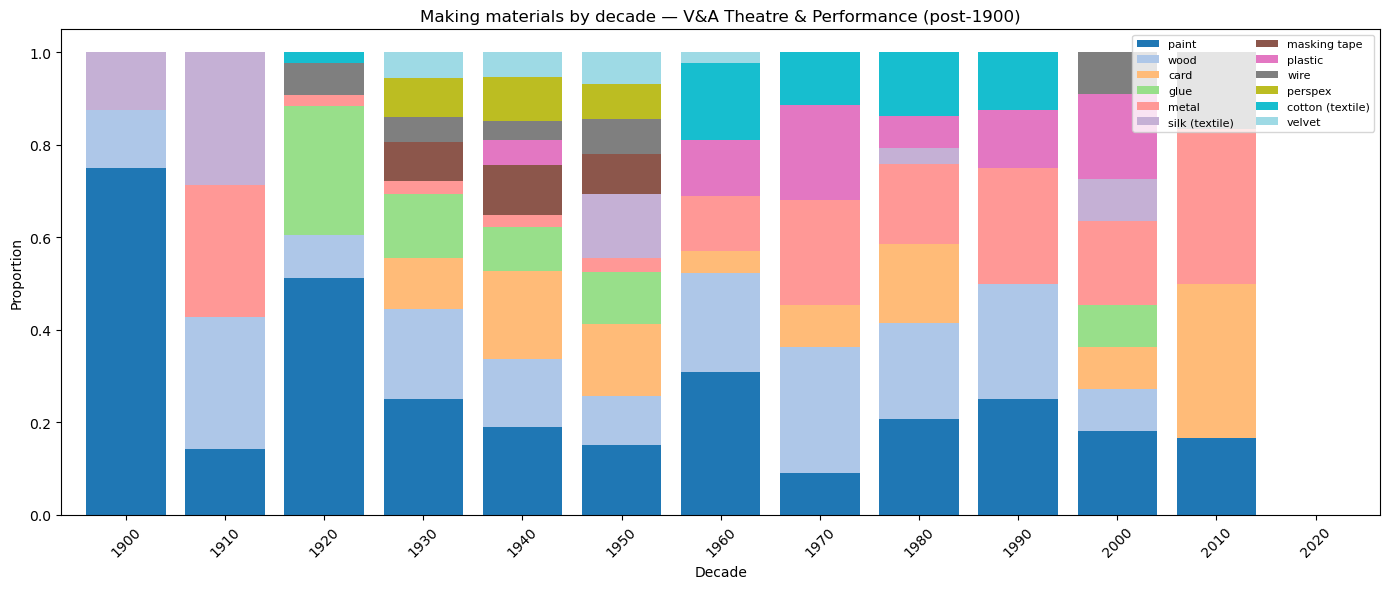

Done!


In [10]:
# Build decade x material matrix
decades = sorted(decade_materials.keys())
matrix = pd.DataFrame(
    {decade: [decade_materials[decade].get(m, 0) for m in top_materials]
     for decade in decades},
    index=top_materials
).T

# Normalise by row (proportion within each decade)
matrix_pct = matrix.div(matrix.sum(axis=1), axis=0).fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
matrix_pct.plot(kind="bar", stacked=True, ax=ax, 
                colormap="tab20", width=0.8)

ax.set_title("Making materials by decade — V&A Theatre & Performance (post-1900)")
ax.set_xlabel("Decade")
ax.set_ylabel("Proportion")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("materials_by_decade.png", dpi=150)
plt.show()
print("Done!")


In [11]:
print(df_20c["objectType"].value_counts())


objectType
Set model          119
Poster              53
Print               50
Set design          36
Theatre costume     32
                  ... 
Dance Costume        1
Card Game            1
Badge                1
Map                  1
Miniature            1
Name: count, Length: 79, dtype: int64


In [12]:
df_sets = df_20c[df_20c["objectType"] == "Set model"].copy()

print("Set models by decade:")
print(df_sets["decade"].value_counts().sort_index())
print()
print("Total:", len(df_sets))

Set models by decade:
decade
1900     1
1910     2
1920     7
1930     7
1940    12
1950    23
1960    19
1970    14
1980    15
1990    10
2000     4
2010     5
Name: count, dtype: int64

Total: 119


In [13]:
print(df_sets[df_sets["decade"] == 1900][
    ["systemNumber", "title", "year", "materials_parsed"]
].to_string())

   systemNumber                                                                                                                                                                           title    year                  materials_parsed
77     O1115252  Set model by Henry Emden for the 'London Bridge' scene in J. Comyns Carr's stage adaption of Charles Dicken's 'Oliver Twist', His Majesty's Theatre, London, June 10th 1905.    1905.0  [cardboard, watercolour (paint)]


In [14]:
decade_mats_sets = {}

for decade, group in df_sets.groupby("decade"):
    all_mats = [
        m for sublist in group["materials_parsed"]
        for m in sublist
        if m.lower() not in documentation_materials
    ]
    decade_mats_sets[decade] = Counter(all_mats)

print("\nMaterials per decade:")
for decade in sorted(decade_mats_sets.keys()):
    top = decade_mats_sets[decade].most_common(5)
    print(f"  {decade}: {top}")


Materials per decade:
  1900: [('cardboard', 1), ('watercolour (paint)', 1)]
  1910: [('wood', 1), ('textile', 1)]
  1920: [('paint', 3), ('wood', 3), ('plaster', 1)]
  1930: [('card', 4), ('wood', 4), ('kaolinite (pigment)', 3), ('paint', 3), ('glue', 3)]
  1940: [('wood', 8), ('masking tape', 8), ('paint', 7), ('card', 7), ('glue', 7)]
  1950: [('card', 16), ('glue', 16), ('masking tape', 14), ('wood', 13), ('perspex', 12)]
  1960: [('wood', 8), ('paint', 2), ('metal', 2), ('plastic', 2), ('cloth', 2)]
  1970: [('wood', 7), ('metal', 3), ('felt', 1), ('cardboard', 1), ('paper (fiber product)', 1)]
  1980: [('wood', 6), ('card', 4), ('metal', 4), ('glass', 2), ('water-colour', 1)]
  1990: [('wood', 2), ('cardboard', 1), ('metal', 1), ('composition (material)', 1), ('paint', 1)]
  2000: [('paint', 2), ('cardboard', 1), ('Fome-Cor (TM)', 1), ('wire', 1), ('feather', 1)]
  2010: []


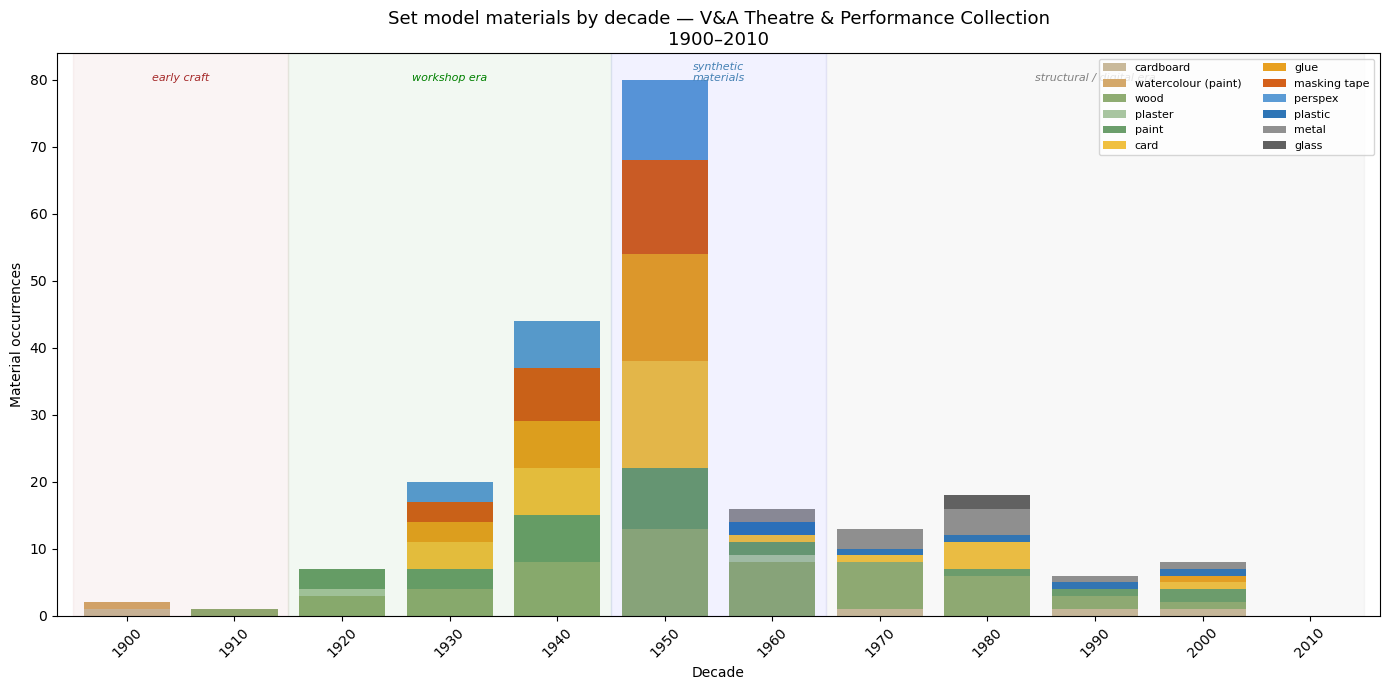

Done!


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Build the matrix
decades = sorted(decade_mats_sets.keys())

# Define materials we want to show - grouped by era character
materials_to_show = [
    'cardboard', 'watercolour (paint)',  # early craft
    'wood', 'plaster', 'paint',          # workshop
    'card', 'glue', 'masking tape',      # model-making
    'perspex', 'plastic',                # industrial synthetics
    'metal', 'glass',                    # structural
]

matrix = pd.DataFrame(
    {decade: [decade_mats_sets[decade].get(m, 0) for m in materials_to_show]
     for decade in decades},
    index=materials_to_show
).T

# Define colours that reflect the grouping
colors = [
    '#c9b99a', '#d4a86a',        # early craft - warm browns
    '#8fac72', '#a8c5a0', '#6b9e6b',  # workshop - greens
    '#f0c040', '#e8a020', '#d4601a',  # model-making - ambers
    '#5b9bd5', '#2e75b6',        # synthetics - blues
    '#909090', '#606060',        # structural - greys
]

fig, ax = plt.subplots(figsize=(14, 7))

matrix.plot(kind="bar", stacked=True, ax=ax,
            color=colors, width=0.8)

ax.set_title("Set model materials by decade — V&A Theatre & Performance Collection\n1900–2010", 
             fontsize=13)
ax.set_xlabel("Decade")
ax.set_ylabel("Material occurrences")
ax.legend(loc="upper right", fontsize=8, ncol=2)

# Add era labels
ax.axvspan(-0.5, 1.5, alpha=0.05, color='brown', label='_')
ax.axvspan(1.5, 4.5, alpha=0.05, color='green', label='_')
ax.axvspan(4.5, 6.5, alpha=0.05, color='blue', label='_')
ax.axvspan(6.5, 11.5, alpha=0.05, color='grey', label='_')

# Era text
ax.text(0.5, ax.get_ylim()[1]*0.95, 'early craft', 
        ha='center', fontsize=8, color='brown', style='italic')
ax.text(3, ax.get_ylim()[1]*0.95, 'workshop era', 
        ha='center', fontsize=8, color='green', style='italic')
ax.text(5.5, ax.get_ylim()[1]*0.95, 'synthetic\nmaterials', 
        ha='center', fontsize=8, color='steelblue', style='italic')
ax.text(9, ax.get_ylim()[1]*0.95, 'structural / digital era', 
        ha='center', fontsize=8, color='grey', style='italic')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("set_model_materials.png", dpi=150)
plt.show()
print("Done!")